<a href="https://colab.research.google.com/github/aeron100/data_science_learning_activities/blob/main/Decision_Tree_Walkthrough.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Confirm your Python environment is ready

In [1]:
import sys
print(sys.version)

import pandas as pd
import sklearn
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
pandas: 2.2.2
scikit-learn: 1.6.1


Why we do this (nontechnical): Before we build anything, we’re checking that the basic “tools in the toolbox” are available and not missing—so we don’t get stuck later with avoidable setup errors. Your setup is solid (Python 3.12 + modern pandas + scikit-learn).

# Create a small dataset we can practice on

In [2]:
from sklearn.datasets import load_iris
import pandas as pd

# Load a clean, built-in dataset (no downloading needed)
iris = load_iris(as_frame=True)

X = iris.data          # features (inputs)
y = iris.target        # labels (what we want to predict)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFirst 5 rows of X:")
print(X.head())
print("\nFirst 10 values of y:")
print(y.head(10).to_list())
print("\nTarget names:", iris.target_names)

X shape: (150, 4)
y shape: (150,)

First 5 rows of X:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

First 10 values of y:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Target names: ['setosa' 'versicolor' 'virginica']


Why we do this (nontechnical): We want a reliable “practice dataset” so we can focus on learning the decision tree steps (train → check → improve) without worrying about data cleaning yet. The data loaded correctly. You now have inputs (measurements) and targets (the flower type), which is exactly what a decision tree needs

# Split the data into Training and Testing sets


In [3]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42     # ensures reproducible results
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (120, 4)
Testing set size: (30, 4)


Why we do this (nontechnical):
Think of this like studying for an exam.

Training data = what the model studies from

Testing data = the final exam it has never seen

If we test on the same data it studied, we don’t know if it actually learned patterns or just memorized. The split worked. You now have:

120 observations for learning

30 observations for the “final exam”

Now we’ll build the actual decision tree.


# Train your first Decision Tree model


In [4]:
from sklearn.tree import DecisionTreeClassifier

# Create the model
tree_model = DecisionTreeClassifier(random_state=42)

# Train (fit) the model using the training data
tree_model.fit(X_train, y_train)

print("Decision tree has been trained.")

Decision tree has been trained.


Why we do this (nontechnical):
This step is where the model learns patterns.

A decision tree works like a series of questions:

Is petal length > X?

Is seal width < Y?

It keeps splitting the data into groups until it can clearly separate the flower types.
This is the “learning phase.” Your model is trained. Now we will check how well it does on the “final exam” data it never saw.

# Make predictions and measure accuracy

In [5]:
from sklearn.metrics import accuracy_score

# Predict on the test set
y_pred = tree_model.predict(X_test)

# Calculate accuracy
acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", acc)

Test accuracy: 1.0


Why we do this (nontechnical):
We’re verifying whether the tree learned a general rule that works on new cases, not just the examples it studied. Accuracy is simply “what fraction did it get right?” 1.0 accuracy means the model correctly predicted 100% of the test cases.
That’s common with the Iris dataset because it’s very clean and easy to separate.

Now we’ll do something important from a coaching perspective: look inside the model so it’s not a black box.

# See what the model thinks is important

In [6]:
import pandas as pd

# Get feature importance scores
importance = tree_model.feature_importances_

# Put into a readable table
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

             Feature  Importance
2  petal length (cm)    0.906143
3   petal width (cm)    0.077186
1   sepal width (cm)    0.016670
0  sepal length (cm)    0.000000


Why we do this (nontechnical):
A decision tree makes decisions by asking questions about features.
This step shows:

Which measurements the model relied on most

What information actually drives the predictions

In real projects, this helps you answer:

“What factors matter most?”

“Does this make business sense?”Your model is mostly using:

Petal length (~91%) → the main decision factor

Petal width (~8%) → secondary

Sepal measurements barely matter

This tells us the species are primarily distinguished by petal size, which matches biological reality. This is exactly the kind of insight decision trees are valued for.

# Visualize the decision tree:

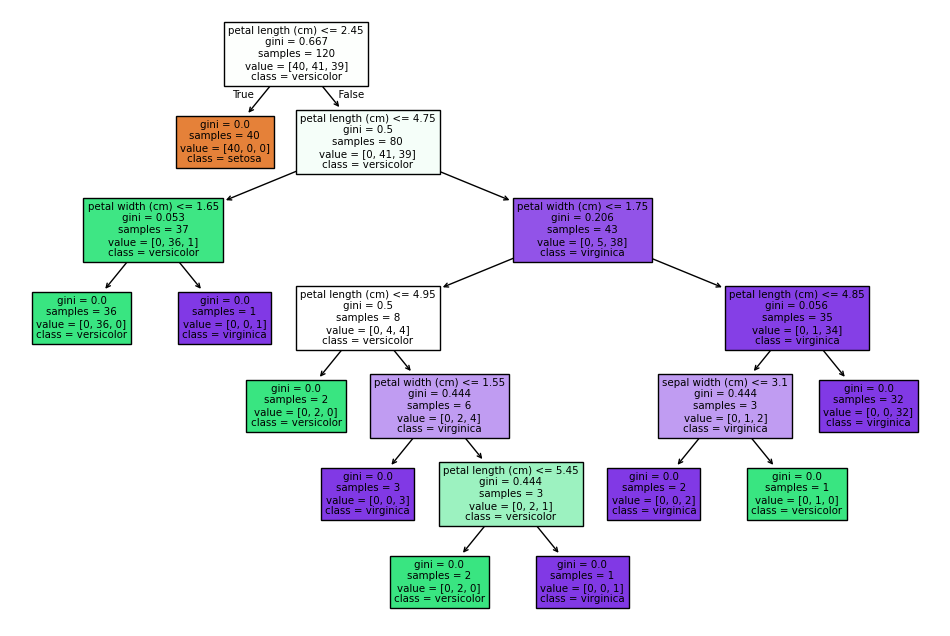

In [7]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True
)
plt.show()

Why we do this (nontechnical):
This creates a flowchart of the model’s thinking.

Each box shows:

The question being asked (e.g., petal length ≤ 2.45)

How many samples are in that group

Which class the model predicts

This helps you:

Explain the model to others

Validate that the logic makes sense

Build trust (especially important in business or institutional settings) Now you’ve seen the model’s decision logic visually. That’s a major milestone.

Now we’ll take an important professional step: limit the tree’s complexity.

# Train a simpler (controlled) decision tree

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create a simpler tree (limit depth)
simple_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train it
simple_tree.fit(X_train, y_train)

# Test it
y_pred_simple = simple_tree.predict(X_test)
acc_simple = accuracy_score(y_test, y_pred_simple)

print("Simple tree accuracy:", acc_simple)

Simple tree accuracy: 1.0


Why we do this (nontechnical):
We are telling the model:

“Don’t keep asking too many detailed questions. Focus only on the most important splits.”

This helps:

Prevent overfitting

Make the model easier to explain

Improve performance on real-world data

In practice, this is called model tuning — finding the right balance between simple and accurate.You now have:

Full tree accuracy: 1.0

Simpler tree accuracy: 1.0

What this means (nontechnical insight):
The extra complexity in the original tree was not necessary.
A small set of simple rules is enough to classify the flowers perfectly.

In real data science work, this is ideal:

Simpler model

Same performance

Easier to explain

Lower risk of overfitting

This is exactly the kind of model stakeholders trust.

# Visualize the simpler tree

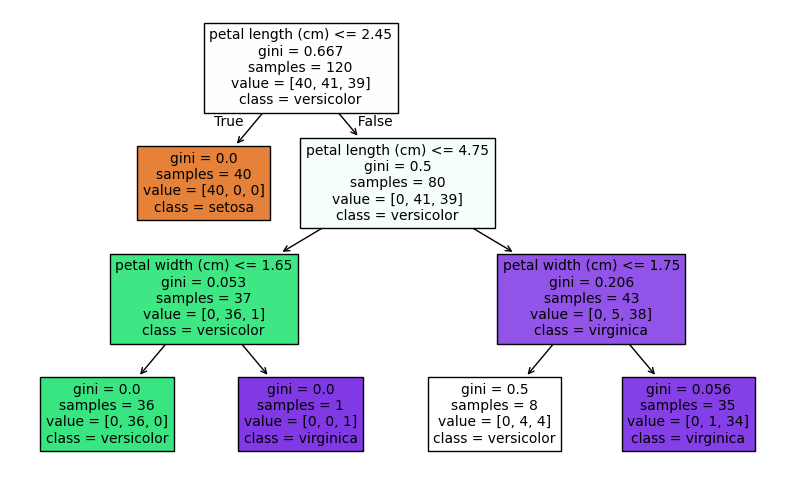

In [9]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plot_tree(
    simple_tree,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True
)
plt.show()

Why we do this (nontechnical):
This helps you see:

Fewer decision steps

Cleaner logic

The core rules the model actually needs

In professional settings, this version is often what you would present in a report or dashboard.

# Predict a new observation

In [10]:
import pandas as pd

# Create a new flower measurement (example values)
new_sample = pd.DataFrame([{
    "sepal length (cm)": 5.0,
    "sepal width (cm)": 3.4,
    "petal length (cm)": 1.5,
    "petal width (cm)": 0.2
}])

# Make prediction using the simpler model
prediction = simple_tree.predict(new_sample)

# Convert numeric prediction to flower name
predicted_class = iris.target_names[prediction[0]]

print("Predicted class:", predicted_class)

Predicted class: setosa


Why we do this (nontechnical):
This simulates a real scenario:

A new case arrives

The model applies its learned rules

It returns a decision

In practice, this could be:

Approve / deny a loan

Predict student success risk

Classify a customer segment

Your model predicted setosa, which makes sense because the petal measurements are small, and earlier we saw that petal size is the main decision factor.